In [1]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# Now I want to sweep over N ions, limit the maximum number of tweezer beams to 2, and fix one cooling ion

I know the cooling time per mode is inversely proportional to the max of lamb-dicke parameter of mode (max meaning I'm picking out which ion in each mode has the maximum lamb-dicke)

I'm assuming that the k-vector part of the lamb-dicke parameter is equal per ion, so I'm only going to consider the mode-vector coupling term for now

This means I'll pick out the mode-vector coupling term per mode to find the time per mode

Then I'll sum up all of those times per mode to get the total time

In [ ]:
def tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    P_opt,
    w0,
    max_tweezed=1,
    qubit_wavelength=729e-9,
    theta=0
):
    """
    Compute all tweezer combinations and corresponding radial mode frequencies,
    including power dependence and tweezed/untweezed mode separation.

    mode_calc_r is expected to return a list of tuples:
        [(freq1, eigvec1), (freq2, eigvec2), ...]
    """

    import numpy as np
    import itertools
    import pandas as pd

    # --- Normalize inputs ---
    if np.isscalar(N_list):
        N_list = [int(N_list)]
    if np.isscalar(P_opt):
        P_opt = [P_opt]

    pi = np.pi
    rows = []

    # --- Helper functions ---
    def max_eig_index(eigvec):
        """Return max amplitude and its ion index"""
        idx = np.argmax(np.abs(eigvec))
        return eigvec[idx], idx

    def max_eig_index_no_tweeze(eigvec, tweezed):
        N = len(eigvec)
        ion_indices = np.arange(N)
        mask = ~np.isin(ion_indices, tweezed)  # untweezed ions only
        if np.any(mask):
            eig_untweezed = eigvec[mask]
            ions_untweezed = ion_indices[mask]
            idx_local = np.argmax(np.abs(eig_untweezed))
            return eig_untweezed[idx_local], ions_untweezed[idx_local]
        else:
            return np.nan, np.nan

    def sum_no_tweeze(arr, tweezed, N):
        ion_indices = np.arange(N)
        mask = ~np.isin(ion_indices, tweezed)
        if np.any(mask):
            return np.sqrt(np.sum(arr[mask] ** 2))
        else:
            return np.nan

    # --- Loop over number of ions ---
    for N in N_list:
        # Generate all possible tweezer combinations
        all_combos = []
        for r in range(0, max_tweezed + 1):
            all_combos.extend(itertools.combinations(range(N), r))

        # RF trap setup
        w_rf_r = f_rf_r * 2 * pi
        w_rf_r_list = np.full(N, w_rf_r)
        ueq = ion_spacing(N, f_rf_r)[0]

        # --- Loop over optical powers ---
        for P_total in P_opt:
            for tweezed_positions in all_combos:
                n_tweezed = len(tweezed_positions)
                P_per = P_total / n_tweezed if n_tweezed > 0 else 0.0

                # Compute tweezer potential for this configuration
                pot = potential(omega_tweezer, linewidths, omega_res, P_per, w0)
                w_tw_r = omega_tweezer_r(pot, w0, m)

                # Combine tweezed and untweezed radial frequencies
                combo = np.array([
                    np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2) if i in tweezed_positions else w_rf_r_list[i]
                    for i in range(N)
                ])

                # --- Compute radial modes ---
                modes = mode_calc_r(m, combo, ueq, N)

                # Extract frequencies and eigenvectors
                freqs = np.array([f for f, v in modes], dtype=float)
                eigvecs = np.vstack([np.ravel(v) for f, v in modes])  # shape (n_modes, N)

                # --- Initialize row ---
                row = {
                    "N": N,
                    #"P_total (W)": P_total,
                    "Tweezed ions": tweezed_positions,
                    "P_per_tweezer (W)": P_per,
                    #"Combined radial frequencies": combo,
                }

                # --- Loop over modes dynamically ---
                for mode_index, (f, eigvec) in enumerate(modes):
                    eigvec = np.ravel(eigvec)
                    mode_sum_no_tweeze = sum_no_tweeze(eigvec, tweezed_positions, N)
                    mode_max, mode_max_index = max_eig_index(eigvec)
                    mode_max_no_tweeze, mode_max_no_tweeze_index = max_eig_index_no_tweeze(eigvec, tweezed_positions)

                    # Store per-mode data
                    row[f"Mode{mode_index}_freq"] = f
                    row[f"Mode{mode_index}_eigvec"] = eigvec
                    #row[f"Mode{mode_index}_max"] = mode_max
                    #row[f"Mode{mode_index}_max_index"] = mode_max_index
                    #row[f"Mode{mode_index}_max_no_tweeze"] = mode_max_no_tweeze
                    #row[f"Mode{mode_index}_max_no_tweeze_index"] = mode_max_no_tweeze_index

                # --- Unique mode→ion mapping (by absolute value, preserving sign) ---
                abs_eigs = np.abs(eigvecs)
                used = set()
                mode_to_ion_indices = []
                mode_to_ion_amplitudes = []

                for mode_i in range(abs_eigs.shape[0]):
                    order = np.argsort(abs_eigs[mode_i])[::-1]
                    for idx in order:
                        if idx not in used:
                            # pick by largestx |amplitude| but store signed value
                            mode_to_ion_indices.append(int(idx))
                            mode_to_ion_amplitudes.append(float(eigvecs[mode_i, idx]))
                            used.add(idx)
                            break

                row["Mode→Ion indices"] = mode_to_ion_indices
                row["Mode→Ion amplitudes"] = mode_to_ion_amplitudes

                # --- Maximum (by |amplitude|) of assigned amplitudes ---
                row["Max amplitude (mode→ion)"] = (
                    max(map(abs, mode_to_ion_amplitudes)) if mode_to_ion_amplitudes else np.nan
                )

                # --- Store completed row ---
                rows.append(row)

    return pd.DataFrame(rows)


In [ ]:
N = np.arange(3,4)
P_opt = [1]
data= tweezer_combos_full_radial(omega_tweezer,linewidths,omega_res,m,mode_calc_r,N,f_rf_r,P_opt,w0)

In [ ]:
data

In [ ]:
def compute_mode_coupling_row(row, qubit_wavelength=729e-9, theta_deg=0):
    amps = np.atleast_1d(row.get('Mode→Ion amplitudes', []))
    # gather matching Mode{i}_freq entries (0 -> Mode0_freq, 1 -> Mode1_freq, ...)
    freqs = []
    for i in range(len(amps)):
        freqs.append(row.get(f"Mode{i}_freq", np.nan))
    amps = np.array(amps, dtype=float)
    freqs = np.array(freqs, dtype=float)

    # if any freq missing return array of nans with same length as amps
    if amps.size == 0 or np.any(np.isnan(freqs)):
        return np.full(amps.shape, np.nan, dtype=float)

    # prefactor and corrected sqrt (sqrt(hbar / (2*m*omega)))
    prefactor = (2 * np.pi * qubit_wavelength / c) * np.cos(np.radians(theta_deg))
    coupling = amps * prefactor * np.sqrt(hbar / (2 * m * freqs))
    return coupling

# create column with per-row arrays
data['Mode→Ion_coupling'] = data.apply(_compute_mode_coupling_row, axis=1)


In [ ]:
compute_mode_coupling_row()
data['Mode→Ion_coupling'] = data.apply(compute_mode_coupling_row, axis=1)


In [ ]:
#next step: take the list of amplitudes and convert it to times, plot the minimum time per N and sweep over N

# look at this one later, it doubles up on indices for a tweezed ion

In [ ]:
# ...existing code...
def tweezer_combos_full_radial_with_mode_mapping_ignore_tweezed(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    P_opt,
    w0,
    max_tweezed=1,
    qubit_wavelength=729e-9,
    theta=0,
):
    """
    Computes radial modes and eigenvectors and tracks:
    - Max per mode and no-tweeze max
    - Mode→Ion mapping ignoring tweezed ions (duplicates allowed)
    - Mode→Ion amplitudes and max amplitude
    - Mode→Ion couplings (per-row array and per-mode Mode{i}_coupling columns)
    """

    import numpy as np
    import itertools
    import pandas as pd
    from scipy import constants as _const

    c = _const.c
    hbar = _const.hbar

    if np.isscalar(N_list):
        N_list = [int(N_list)]
    if np.isscalar(P_opt):
        P_opt = [P_opt]

    pi = np.pi
    rows = []

    def max_eig_index(eigvec):
        idx = np.argmax(np.abs(eigvec))
        return eigvec[idx], idx

    def max_eig_index_no_tweeze(eigvec, tweezed):
        N = len(eigvec)
        ion_indices = np.arange(N)
        mask = ~np.isin(ion_indices, tweezed)
        if np.any(mask):
            eig_untweezed = eigvec[mask]
            ions_untweezed = ion_indices[mask]
            idx_local = np.argmax(np.abs(eig_untweezed))
            return eig_untweezed[idx_local], ions_untweezed[idx_local]
        else:
            return np.nan, np.nan

    for N in N_list:
        all_combos = []
        for r in range(0, max_tweezed + 1):
            all_combos.extend(itertools.combinations(range(N), r))

        w_rf_r = f_rf_r * 2 * pi
        w_rf_r_list = np.full(N, w_rf_r)
        ueq = ion_spacing(N, f_rf_r)[0]

        for P_total in P_opt:
            for tweezed_positions in all_combos:
                n_tweezed = len(tweezed_positions)
                P_per = P_total / n_tweezed if n_tweezed > 0 else 0.0

                pot = potential(omega_tweezer, linewidths, omega_res, P_per, w0)
                w_tw_r = omega_tweezer_r(pot, w0, m)

                combo = np.array([
                    np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2) if i in tweezed_positions else w_rf_r_list[i]
                    for i in range(N)
                ])

                modes = mode_calc_r(m, combo, ueq, N)

                # frequencies and eigenvector matrix (n_modes, N)
                freqs = np.array([f for f, v in modes], dtype=float)
                eigvecs = np.vstack([np.ravel(v) for f, v in modes]) if len(modes) else np.empty((0, N))

                row = {
                    "N": N,
                    "P_total (W)": P_total,
                    "Tweezed ions": tweezed_positions,
                    "P_per_tweezer (W)": P_per,
                    "Combined radial frequencies": combo,
                }

                mode_to_ion_indices = []
                mode_to_ion_amplitudes = []

                for mode_index, (f, eigvec) in enumerate(modes):
                    eigvec = np.ravel(eigvec)
                    mode_max, mode_max_index = max_eig_index(eigvec)
                    mode_max_no_tweeze, mode_max_no_tweeze_index = max_eig_index_no_tweeze(eigvec, tweezed_positions)

                    row[f"Mode{mode_index}_max"] = mode_max
                    row[f"Mode{mode_index}_max_index"] = mode_max_index
                    row[f"Mode{mode_index}_max_no_tweeze"] = mode_max_no_tweeze
                    row[f"Mode{mode_index}_max_no_tweeze_index"] = mode_max_no_tweeze_index

                    # --- Mode→Ion mapping ignoring tweezed ions ---
                    candidates = [i for i in range(N) if i not in tweezed_positions]
                    if not candidates:
                        mode_to_ion_indices.append(np.nan)
                        mode_to_ion_amplitudes.append(np.nan)
                    else:
                        max_idx_local = candidates[np.argmax(np.abs(eigvec[candidates]))]
                        mode_to_ion_indices.append(int(max_idx_local))
                        mode_to_ion_amplitudes.append(float(eigvec[max_idx_local]))

                row["Mode→Ion indices"] = mode_to_ion_indices
                row["Mode→Ion amplitudes"] = mode_to_ion_amplitudes
                row["Max amplitude (mode→ion)"] = max(
                    map(abs, [x for x in mode_to_ion_amplitudes if not np.isnan(x)])
                ) if any(not np.isnan(x) for x in mode_to_ion_amplitudes) else np.nan

                # --- Compute mode→ion coupling (per-row array + per-mode columns) ---
                k = 2 * np.pi / qubit_wavelength
                proj = np.cos(np.radians(theta))
                couplings = []
                for i, amp in enumerate(mode_to_ion_amplitudes):
                    # amplitude may be nan
                    try:
                        amp_f = float(amp)
                    except Exception:
                        amp_f = np.nan

                    freq_i = freqs[i] if (i < len(freqs)) else np.nan

                    if np.isnan(amp_f) or np.isnan(freq_i) or freq_i == 0:
                        val = np.nan
                    else:
                        # use sqrt(hbar/(2*m*omega)) where freqs are angular frequencies expected from mode_calc_r
                        val = amp_f * k * proj * np.sqrt(hbar / (2 * m * freq_i))

                    couplings.append(float(val) if not np.isnan(val) else np.nan)
                    row[f"Mode{i}_coupling"] = float(val) if not np.isnan(val) else np.nan

                row["Mode→Ion_coupling"] = couplings

                rows.append(row)

    return pd.DataFrame(rows)
# ...existing code...


In [ ]:
N = np.arange(3,4)
P_opt = [100e-3]
data= tweezer_combos_full_radial_with_mode_mapping_ignore_tweezed(omega_tweezer,linewidths,omega_res,m,mode_calc_r,N,f_rf_r,P_opt,w0)

In [ ]:
data

In [ ]:
#what is the two photon rabi frequency for each of these?????
#effective rabi frequency, g = eta*Omega/2 from Sideband Thermometry of Ion Crystals -- PRX Quantum published in 2023
#and regular Rabi frequency is= 
# Rabi_squared = [(linewidths[0]*6*pi*c**2)/(hbar*omega_res[0]**3) * I , linewidths[1] *(6*pi*c**2)/(hbar*omega_res[1]**3) * I]
#but i need the linewidths and omegares for the qubit transition 
#or refer to equation 2.17 from the Hempel thesis
#also, use I = 2P/(pi w0^2)

1. find the saturation intensity of the qubit transition
2. insert the linewidth and resonant frequency of the qubit transition
3. find the rabi frequency with the equation I used above
4. take my mode vector contribution values and convert them to lamb-dicke factors
5. find the effective rabi frequency

linewidth_729 = 136e-3*2*pi
omega_res_729 = 

# brute force calculation of every single ion coupling to every single mode -- radial only

In [4]:
N = np.arange(3,4)
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
N3= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    P_opt,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3)
mode0_list = result["mode_lists"][0]
mode1_list = result["mode_lists"][1]
mode2_list = result["mode_lists"][2]
print(mode0_list)
untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[2]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[3]
min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)
best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])



[((), array([0.57735027, 0.57735027, 0.57735027])), ((0,), array([-0.9836896 , -0.17081997, -0.05634995])), ((1,), array([0.21289466, 0.95359935, 0.21289466])), ((2,), array([0.05634995, 0.17081997, 0.9836896 ]))]


KeyError: 0

In [32]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    P_opt,
    w0,
    max_tweezed=1
):
    # 1. Build eigenvector lists
    df = tweezer_combos_full_radial(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        P_opt,
        w0,
        max_tweezed=max_tweezed,
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]

    # 2. Remove the untweezed configuration (index 0)
    mode_lists_dict.pop(0, None)

    # 3. Extract in mode-index order
    mode_lists = [mode_lists_dict[k] for k in sorted(mode_lists_dict.keys())]

    if not mode_lists:
        return []

    # 4. Combine modes
    combos = combine_lists(*mode_lists)

    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}

    # 6. Filter by max(min(abs))
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}

    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    return winners

def run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    P_opt,
    w0
):
    # Build eigenvector lists
    df = tweezer_combos_full_radial(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        P_opt,
        w0,
        max_tweezed=0  # untweezed only
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]

    # Keep only untweezed (index 0)
    untweezed_list = mode_lists_dict.get(0, [])
    if not untweezed_list:
        return []

    # Combine modes (if multiple modes exist)
    combos = combine_lists(untweezed_list)

    # Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}

    # Filter by max(min(abs))
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}

    # Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    return winners



In [50]:
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6

results = []
for Ni in range(2, 10):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results.append((Ni, winners))

untweezed_results = []
for Ni in range(2, 10):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))


8 8
8 8


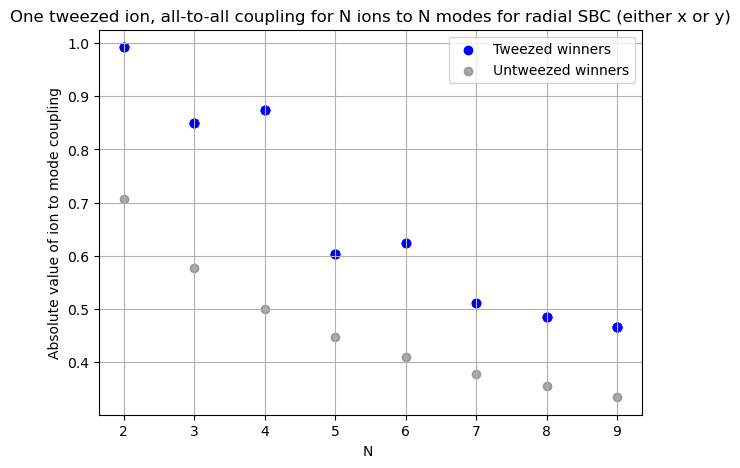

In [58]:
x = [N for N, winners in results]
y = [abs(winners[0][2]) for N, winners in results]
print(len(x), len(y))

for N, winners in results:  # results = tweezed winners
    for w in winners:
        x.append(N)
        y.append(abs(w[2]))

x_untweezed = [N for N, winners in untweezed_results]
y_untweezed = [abs(winners[0][2]) for N, winners in untweezed_results]
print(len(x_untweezed), len(y_untweezed))

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)
plt.xlabel("N ")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes for radial SBC (either x or y)")
plt.grid(True)
plt.legend()
plt.show()

In [62]:
print(results[4])

(6, [(3, (5, 0, 4, 1, 3), 0.624436445335665)])


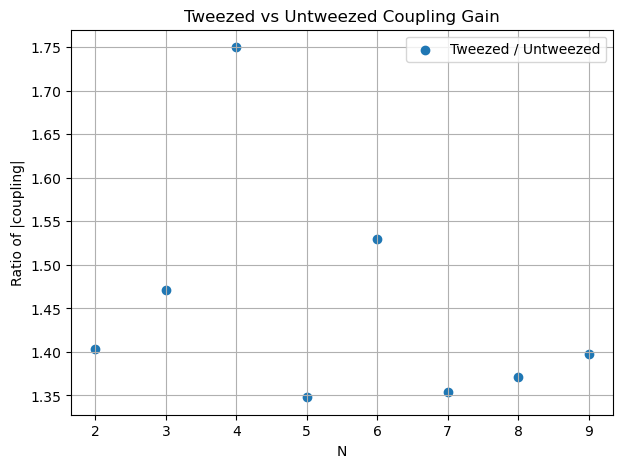

In [60]:
# Best tweezed only
x = [N for N, winners in results]
y = [abs(winners[0][2]) for N, winners in results]

# Best untweezed only
x_untweezed = [N for N, winners in untweezed_results]
y_untweezed = [abs(winners[0][2]) for N, winners in untweezed_results]

# Convert to arrays
x = np.array(x)
y = np.array(y)
x_untweezed = np.array(x_untweezed)
y_untweezed = np.array(y_untweezed)

# Compute ratio
ratio = y / y_untweezed

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, ratio, label='Tweezed / Untweezed')
plt.xlabel("N")
plt.ylabel("Ratio of |coupling|")
plt.title("Tweezed vs Untweezed Coupling Gain")
plt.grid(True)
plt.legend()
plt.show()


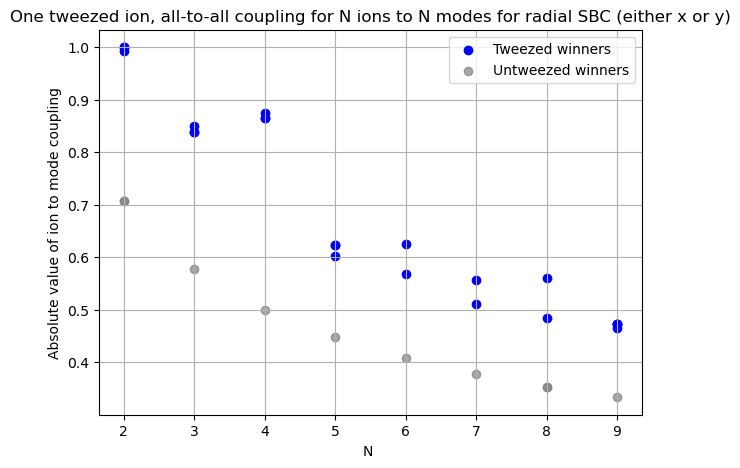

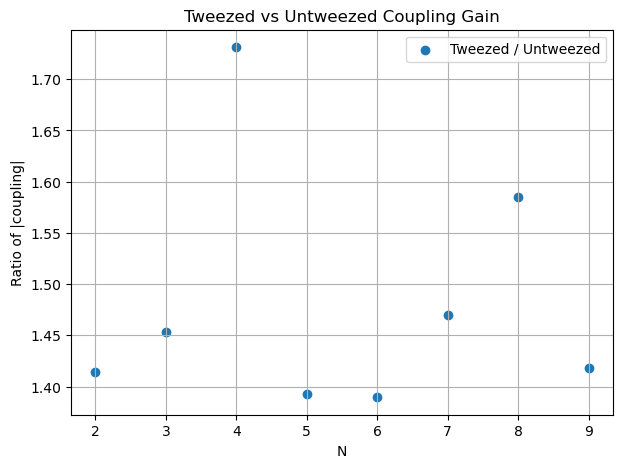

In [61]:
P_opt = [1]
w0 = 1e-6
f_rf_r = 1e6

results_high_power = []
for Ni in range(2, 10):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_high_power.append((Ni, winners))

untweezed_results_high_power = []
for Ni in range(2, 10):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        P_opt,
        w0,
    )
    untweezed_results_high_power.append((Ni, winners))
x = [N for N, winners in results]
y = [abs(winners[0][2]) for N, winners in results]

for N, winners in results_high_power:  # results = tweezed winners
    for w in winners:
        x.append(N)
        y.append(abs(w[2]))

# x_untweezed, y_untweezed for untweezed winners
x_untweezed = []
y_untweezed = []

for N, winners in untweezed_results_high_power:
    for w in winners:
        x_untweezed.append(N)
        y_untweezed.append(abs(w[2]))

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)
plt.xlabel("N ")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes for radial SBC (either x or y)")
plt.grid(True)
plt.legend()
plt.show()
# Best tweezed only
x = [N for N, winners in results]
y = [abs(winners[0][2]) for N, winners in results_high_power]

# Best untweezed only
x_untweezed = [N for N, winners in untweezed_results_high_power]
y_untweezed = [abs(winners[0][2]) for N, winners in untweezed_results_high_power]

# Convert to arrays
x = np.array(x)
y = np.array(y)
x_untweezed = np.array(x_untweezed)
y_untweezed = np.array(y_untweezed)

# Compute ratio
ratio = y / y_untweezed

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, ratio, label='Tweezed / Untweezed')
plt.xlabel("N")
plt.ylabel("Ratio of |coupling|")
plt.title("Tweezed vs Untweezed Coupling Gain")
plt.grid(True)
plt.legend()
plt.show()
